PRIMA PARTE DEL PROGRAMMA FA modellizzazione dell'emissione del disco di Shakura-Sunyaev, ovvero dove ogni raggio del disco emette come un corpo nero 
    1) data massa buco nero -> Ledd -> Ldisk -> Mdot  ; fisso anche Rin e Rout 
    2) creo vettore dei raggi(tra Rin e Rout) e vettore delle frequenze(tra 10^13 e 10^17 Hz) \\
    3) definisco temperatura a dato R (in funzione di Mbh,Mdot; R)
    4) data la legge di Planck del corpo nero, creo matrice Bnu(nu, R) e la calcolo per tutte le freuqenze e tutti i raggi
    5) calcolo con metodo trapezoid di numpy l'integrale di R*Bnu(nu,R) a R che va da Rin a Rout, ottenendo la Luminosità Lnu(Mbh,Mdot; nu): questa è la luminosità a data frequenza del disco totale; NB: moltiplico l'integrale per 4*pi^2 
    6) plotto Lnu*nu vs nu in scala bilogaritmica; in realtà sull'asse delle y (all'interno del log) metto Lnu*nu*2*cos(theta), dove theta è l'angolo tra la normale alla superficie piatta del disco e noi: questa correzione (piccola dato che theta è pochi gradi) è data dal fatto che se disco del blazar è inclinato a noi arriva meno luce
    7) testo la bontà del mio programma di emissione del disco facendo 4 prove: 
    prima->calcolo nu_peak*Lnu_peak, dovrebbe venire circa 0.5*Ldisk 
    seconda-> integro Lnu su tutte le frequenze, dovrei ottenere Ldisk (NB:qui è importante avere 10^17 Hz invece che 10^16 perchè così considero la parte finale della coda)
    terza-> modifico Mbh tenendo invece costante Mdot(e anche Ledd, cha calcolo con Mbh scelta di rif), dovrei vedere spostamento picco emissione verso sinistra al crescere di Mbh
    quarta-> modifico Mdot, o meglio Ldisk moltiplicando Ledd per diversi fattori (1%,10%,30%), e tengo fissa Mbh, dovrei vedere spostamento picco verso alto e destra al crescere del fattore

NB: nella fine della terza e quarta prova inoltre rifaccio anche la prima prova per le diverse curve plottate

In [27]:
import numpy as np
import matplotlib.pyplot as plt

#parametri e costanti per il disco di accrescimento: c, G, h, kB, sigma, Msun

c = 2.99792458e10          # cm/s
G = 6.67430e-8             # unità cgs = cm^3 g^-1 s^-2
h = 6.62607015e-27         # erg*s  
kB = 1.380649e-16          # erg/K  #costante di Boltzmann
sigma = 5.670374419e-5     # erg cm^-2 s^-1 K^-4  #costante di Stefan-Boltzmann
Msun = 1.98847e33          # g

MBH = 1e8 * Msun           
eta = 0.083                #efficienza di conversione massa-energia  #0.083 meglio di 0.1, anche se 0.08 vuol dire che considera disco fermo, ma in realtà ruoterebbe
Ledd = 1.3e38 * (MBH / Msun)  # erg/s  
Ldisk = 0.1 * Ledd            # erg/s
Mdot = Ldisk / (eta * c**2)   # g/s  #tasso di accrescimento

Rs = 2 * G * MBH / c**2     # cm 
Rin = 3 * Rs                # raggio interno del disco
Rout = 3000 * Rs            # raggio esterno del disco

In [28]:
# vettore dei raggi
Nr = 2000  # numero di punti radiali
R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)  # cm

In [29]:
# calcolo della temperatura in funzione della MBH, Mdot e R
f = 1.0 - np.sqrt(Rin / R)
f = np.clip(f, 0.0, None)  # evito valori negativi per R<Rin
T = ((3*G*MBH*Mdot)/(8*np.pi*sigma*R**3) * f)**0.25  # K

In [30]:
# vettore delle frequenze
Nnu = 400 # numero di punti in frequenza presi
nu = np.logspace(13, 17, Nnu)  # Hz     #meglio consideare fino a 10^17 soprattutto per quando calcolo le luminosità di ionizzazione delle linee 

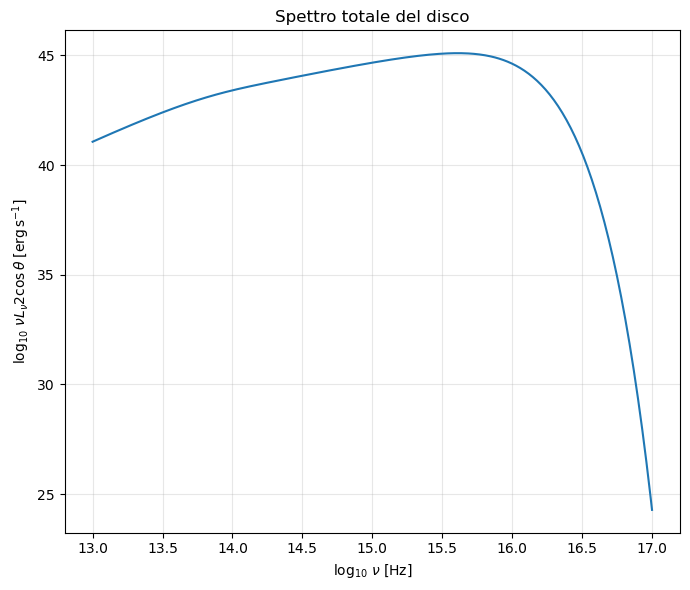

In [31]:
# inizializzo matrice Bnu con dimensioni (Nnu, Nr): righe=frequenze, colonne=raggi e quindi temperature
Bnu = np.zeros((Nnu, Nr))  

# calcolo di B_nu(nu, T) per ogni frequenza e temperatura
for j in range(Nr): #loop sui raggi
    x = h * nu / (kB * T[j])  #array di dimensione (Nnu,) con x per ogni frequenza a quel raggio
    x = np.clip(x, 1e-12, 700.0) # evito overflow per valori di x grandi 
    Bnu[:, j] = (2*h*nu**3 / c**2) / (np.exp(x) - 1.0) #calcolo di Bnu per ogni frequenza a quel raggio, memorizzato nella matrice Bnu

# calcolo di L(nu) integrando su R
integrand = R[None, :] * Bnu                  # ATT: se non metto none negli R si sballa perchè R è un array di dimensione (Nr,) e Bnu è (Nnu, Nr); con none invece R diventa (1, Nr), così integrand ha dimensione (Nnu, Nr)
I_nu = np.trapezoid(integrand, R, axis=1)     # integrale su R per ogni frequenza, restituisce un array di dimensione (Nnu,) con I_nu per ogni frequenza
Lnu = 4 * np.pi**2 * I_nu                     # L(nu) per ogni frequenza, array di dimensione (Nnu,)
nuLnu = nu * Lnu

theta = 3.0 * np.pi / 180.0  # angolo di osservazione del disco rispetto alla normale al disco che è verso di noi, in radianti (3 gradi)
#plot dello spettro totale del disco in forma nu*L(nu) vs nu
plt.figure(figsize=(7,6))
#calcolo nu*L(nu)*coseno dell'angolo theta definito prima
plt.plot(np.log10(nu), np.log10(nuLnu *2* np.cos(theta)), label=r'$L_\mathrm{disk} = 0.1 L_\mathrm{Edd}$')
plt.xlabel(r'$\log_{10}\,\nu \;[\mathrm{Hz}]$')
plt.ylabel(r'$\log_{10}\,\nu L_\nu 2\cos\theta \;[\mathrm{erg\,s^{-1}}]$')
plt.title('Spettro totale del disco')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# PRIMA PROVA : calcolo nu_peak*L(nu_peak) e confronto con 0.5*Ldisk, perchè --> il valore del picco indica dove viene emessa la maggior parte dell’energia e Ldisk è la potenza totale emessa, 
# quindi se il picco è vicino a 0.5*Ldisk significa che la maggior parte dell’energia viene emessa intorno a quella frequenza, e quindi è un buon indicatore della potenza totale del disco. 
# Se invece il picco è molto più basso di 0.5*Ldisk, significa che la maggior parte dell’energia viene emessa a frequenze più basse, e quindi il picco non rappresenta bene la potenza totale del disco.

i_peak = np.argmax(nuLnu) #indice a cui nu*L(nu) è massimo
nu_peak = nu[i_peak] #frequenza a cui nu*L(nu) è massimo
Lnu_peak = Lnu[i_peak] #valore di L(nu) a nu_peak
nuLnu_peaks= nu_peak * Lnu_peak #valore massimo di nu*L(nu)
#nuLnu_peak = nuLnu[i_peak] #valore massimo di nu*L(nu)

target = 0.5 * Ldisk
#print(f"nu_peak = {nu_peak:.3e} Hz")
#print(f"Lnu_peak = {Lnu_peak:.3e} erg/s/Hz")
print(f"nu_peak * Lnu_peak = {nuLnu_peaks:.3e} erg/s")
print(f"0.5 * Ldisk = {target:.3e} erg/s")

nu_peak * Lnu_peak = 6.314e+44 erg/s
0.5 * Ldisk = 6.500e+44 erg/s


In [33]:
# SECONDA PROVA : calcolo luminosità totale come integrale di L(nu) su tutte le frequenze e confronto con Ldisk, perchè il rate lo avevo calcolato come Ldisk/(eta*c^2) quindi se l'integrale di L(nu) su tutte le frequenze è uguale a Ldisk, allora il rate è coerente con la potenza totale emessa dal disco

Ltot = np.trapezoid(Lnu, nu)
print(f"Ldisk = {Ldisk:.3e} erg/s")
print(f"Ltot  = {Ltot:.3e} erg/s")

Ldisk = 1.300e+45 erg/s
Ltot  = 1.301e+45 erg/s


Mdot_ref (da 1e8 Msun) = 1.743e+25 g/s


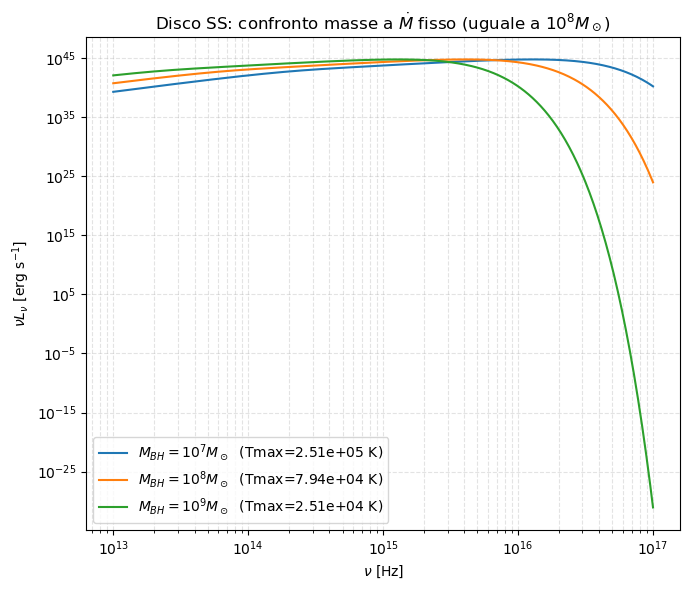

M_BH = 1.0e+07 Msun: nu_peak*L(nu_peak) = 6.315e+44 erg/s, 0.5*Ldisk_ref = 6.500e+44 erg/s
M_BH = 1.0e+08 Msun: nu_peak*L(nu_peak) = 6.314e+44 erg/s, 0.5*Ldisk_ref = 6.500e+44 erg/s
M_BH = 1.0e+09 Msun: nu_peak*L(nu_peak) = 6.314e+44 erg/s, 0.5*Ldisk_ref = 6.500e+44 erg/s


In [34]:
# TERZA PROVA : confronto tra 3 masse BH diverse a Mdot fissato (uguale a quello di 1e8 Msun) e plotto sullo stesso grafico : 
# infatti a parità di tasso di accrescimento, la massa del BH determina la temperatura massima del disco e quindi la frequenza a cui si trova il picco dello spettro
# se aumento la massa del BH, a parità di Mdot, la temperatura massima del disco diminuisce ( T prop (M_bh^-0.5)) e quindi il picco dello spettro si sposta verso frequenze più basse (spettro termico più freddo ha il picco a frequenze più basse)

MBH_ref_msun = 1e8
MBH_ref = MBH_ref_msun * Msun
Ledd_ref = 1.3e38 * (MBH_ref / Msun)   
Ldisk_ref = 0.1 * Ledd_ref
Mdot_ref = Ldisk_ref / (eta * c**2)    
print(f"Mdot_ref (da 1e8 Msun) = {Mdot_ref:.3e} g/s")

# funzione che calcola nu*L(nu) per un disco con massa MBH_msun e tasso di accrescimento fissato a Mdot_fissato
def disk_nuLnu_fissato_mdot(MBH_msun, nu, Mdot_fissato, Nr=2000):
    MBH = MBH_msun * Msun

    # raggi 
    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    # temperatura T(R) con Mdot fissato
    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3*G*MBH*Mdot_fissato)/(8*np.pi*sigma*R**3) * f)**0.25

    # calcolo di B_nu(nu, T) per ogni frequenza e temperatura
    Nnu = len(nu)
    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2*h*nu**3 / c**2) / (np.exp(x) - 1.0)

    # calcolo di L(nu) integrando su R
    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu

    return nu * Lnu, T.max()  # restituisco anche Tmax per confronto tra le curve per testare

# confronto tra 3 masse diverse a Mdot fissato 
masse = [1e7, 1e8, 1e9]

plt.figure(figsize=(7,6))
for M in masse: # per ogni massa calcolo 
    nuLnu, Tmax = disk_nuLnu_fissato_mdot(M, nu, Mdot_ref, Nr=Nr) 
    plt.loglog(nu, nuLnu, label=fr'$M_{{BH}}=10^{int(np.log10(M))} M_\odot$  (Tmax={Tmax:.2e} K)') 

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]')
plt.title(r'Disco SS: confronto masse a $\dot{M}$ fisso (uguale a $10^8M_\odot$)')
plt.grid(True, which="both", ls="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

#calcolo di nu_peak*L(nu_peak) per ogni massa e confronto con 0.5*Ldisk_ref
for M in masse:
    nuLnu, Tmax = disk_nuLnu_fissato_mdot(M, nu, Mdot_ref, Nr=Nr)
    i_peak = np.argmax(nuLnu)
    nu_peak = nu[i_peak]
    Lnu_peak = nuLnu[i_peak] / nu_peak  # ricavo L(nu) a nu_peak da nu*L(nu)
    nuLnu_peak = nu_peak * Lnu_peak
    print(f"M_BH = {M:.1e} Msun: nu_peak*L(nu_peak) = {nuLnu_peak:.3e} erg/s, 0.5*Ldisk_ref = {0.5*Ldisk_ref:.3e} erg/s")


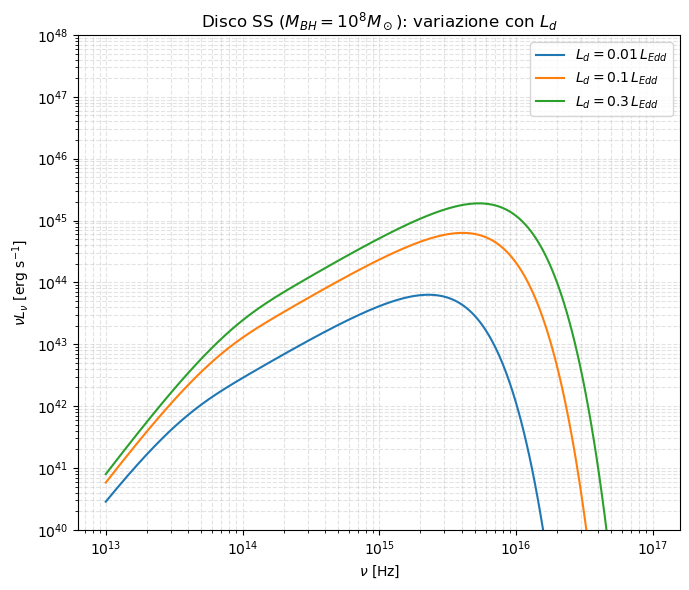

Ldisk = 1.300e+44 erg/s: nu_peak*L(nu_peak) = 6.314e+43 erg/s, 0.5*Ldisk = 6.500e+43 erg/s
Ldisk = 1.300e+45 erg/s: nu_peak*L(nu_peak) = 6.314e+44 erg/s, 0.5*Ldisk = 6.500e+44 erg/s
Ldisk = 3.900e+45 erg/s: nu_peak*L(nu_peak) = 1.894e+45 erg/s, 0.5*Ldisk = 1.950e+45 erg/s


In [35]:
# QUARTA PROVA: modifico la luminosità del disco per vedere come cambia lo spettro al variare di Ldisk, mantenendo fissa la massa del BH a 1e8 Msun, e quindi Mdot variabile
# se aumento Ldisk, aumento Mdot e quindi aumento la temperatura del disco ( perchè Tmax prop (M_dot^1/4)) ; aumentando la temperatura del disco, aumento la frequenza a cui si trova il picco dello spettro
# Inoltre oltre che alla frequenza del picco, anche il valore di nu*L(nu) al picco aumenta con Ldisk

Ledd = 1.3e38 * (MBH / Msun)  # erg/s
f_list = [0.01, 0.1, 0.3]  # Ldisk = f * Ledd

def nuLnu_disk_for_Mdot(MBH, R, nu, Mdot, Rin):
    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3*G*MBH*Mdot)/(8*np.pi*sigma*R**3) * f)**0.25

    # Bnu con loop
    Nnu = len(nu)
    Nr = len(R)
    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2*h*nu**3 / c**2) / (np.exp(x) - 1.0)

    I_nu = np.trapezoid(R[None, :] * Bnu, R, axis=1)
    Lnu = 4*np.pi**2 * I_nu
    return nu * Lnu

plt.figure(figsize=(7,6))
# calcolo nu*L(nu) per ogni fattore di luminosità e plotto sullo stesso grafico
for fEdd in f_list:
    Ldisk = fEdd * Ledd
    Mdot = Ldisk / (eta * c**2)
    nuLnu = nuLnu_disk_for_Mdot(MBH, R, nu, Mdot, Rin)
    plt.loglog(nu, nuLnu, label=fr'$L_d={fEdd:g}\,L_{{Edd}}$')

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]')
plt.ylim(1e40, 1e48)
plt.title(r'Disco SS ($M_{BH}=10^8 M_\odot$): variazione con $L_d$')
plt.grid(True, which="both", ls="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

#calcolo di nu_peak*L(nu_peak) per ogni luminosità e confronto con 0.5*Ldisk 
for fEdd in f_list:
    Ldisk = fEdd * Ledd
    Mdot = Ldisk / (eta * c**2)
    nuLnu = nuLnu_disk_for_Mdot(MBH, R, nu, Mdot, Rin)
    i_peak = np.argmax(nuLnu)
    nu_peak = nu[i_peak]
    Lnu_peak = nuLnu[i_peak] / nu_peak  # ricavo L(nu) a nu_peak da nu*L(nu)
    nuLnu_peak = nu_peak * Lnu_peak
    print(f"Ldisk = {Ldisk:.3e} erg/s: nu_peak*L(nu_peak) = {nuLnu_peak:.3e} erg/s, 0.5*Ldisk = {0.5*Ldisk:.3e} erg/s")

SECONDA PARTE DEL PROGRAMMA CHE FA dato file di energie potenziali e frequenze di ionizzazione associate il calcolo della luminosità delle nu_ioniz data la curva di emissione del disco di prima (facendo integrale di Lnu tra nu_ioniz e nu_max) e ploi plotto curva emissione disco e nu_ioniz in grafico Lnu vs nu
NB: non posso mettere anche le righe che portano a Lion perchè quelle sono calcolate facendo integrale quindi sono in erg/s (non in erg/s/Hz come ho sull'asse delle y)

In [36]:
nu_max = 1e17  # Hz

#Lettura del file di dati 
data = np.genfromtxt("dati.asc", dtype=None, encoding="utf-8")

names, Eion, nu_ion_list = np.genfromtxt(     # data ha shape (N,3)
    "dati.asc",
    dtype=('U20', float, float), #tipo di dato per ogni colonna: stringa di max 20 caratteri per i nomi, float per Eion e nu_ion_list
    unpack=True)


# Calcolo L_ion per ciascuna riga come integrale di L(nu) da nu_ion a nu_max
Lion_list = []
for nu_ion in nu_ion_list:
    # Se nu_ion è sopra nu_max -> nessun contributo nel range scelto
    if nu_ion >= nu_max:
        Lion = 0.0 
    else:
        mask = (nu >= nu_ion) & (nu <= nu_max)
        Lion = np.trapezoid(Lnu[mask], nu[mask])  # erg/s
    Lion_list.append(Lion)

Lion_list = np.array(Lion_list)

# Stampo tabellina con i risultati
print("Transizione   |   E_ion  |  nu_ion [Hz] |  L_ion [erg/s] ")
for n, E, nui, Li in zip(names, Eion, nu_ion_list, Lion_list):
    print(f"{n:>12}  {E:10.3g}  {nui:12.3e}  {Li:12.3e}  ")
#freq alte coprono meno disco

Transizione   |   E_ion  |  nu_ion [Hz] |  L_ion [erg/s] 
          Ha        1.89     4.600e+14     1.231e+45  
          Hb        2.55     6.200e+14     1.196e+45  
          Hg        2.86     6.910e+14     1.180e+45  
          Hd        3.02     7.370e+14     1.168e+45  
        MgII          15     3.630e+15     5.393e+44  
        CIII        54.4     1.315e+16     1.053e+43  
         CIV        47.9     1.158e+16     2.321e+43  
       Mg_pp        80.1     1.940e+16     5.854e+41  


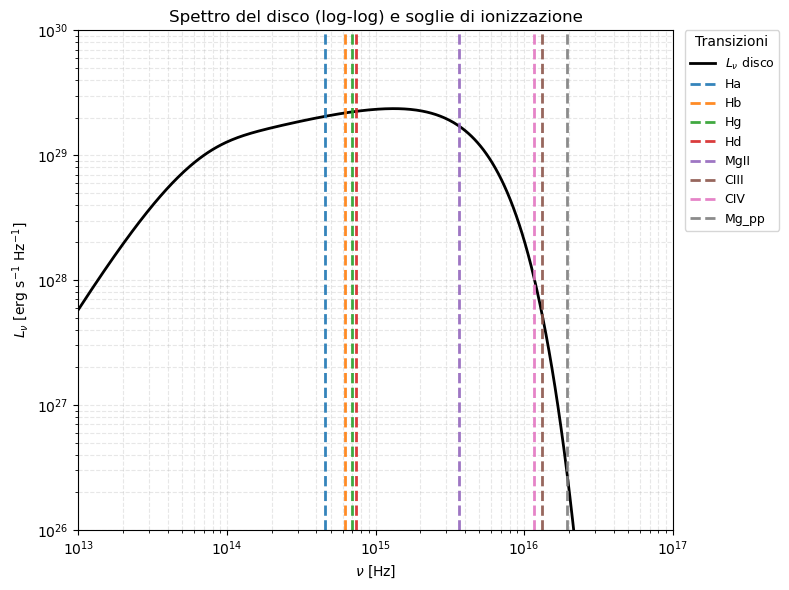

In [37]:
# Plot dello spettro del disco con le soglie di ionizzazione evidenziate
plt.figure(figsize=(8,6))

# curva del disco
plt.loglog(nu, Lnu, lw=2, color="k", label=r'$L_\nu$ disco')  #scala bilogaritmica per vedere meglio
#plt.plot(nu, Lnu, lw=2, color="k", label=r'$L_\nu$ disco')   #scala lineare


# colori diversi e assegnati esplicitamente
cmap = plt.get_cmap("tab10")  # 10 colori distinti (se ho più righe, dovrei passare a 'tab20')
colors = [cmap(i % cmap.N) for i in range(len(names))]

for (n, nui, col) in zip(names, nu_ion_list, colors):
    plt.axvline(nui, ls="--", lw=2, alpha=0.9, color=col, label=str(n))

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]')
plt.xlim(1e13, 1e17)
plt.ylim(1e26,1e30)
plt.title(r'Spettro del disco (log-log) e soglie di ionizzazione')
plt.grid(True, which="both", ls="--", alpha=0.3)

# legenda fuori dal grafico (così non copre la curva) con anche i valori di nu_ion
plt.legend(title="Transizioni", fontsize=9, title_fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

plt.tight_layout()
plt.show()

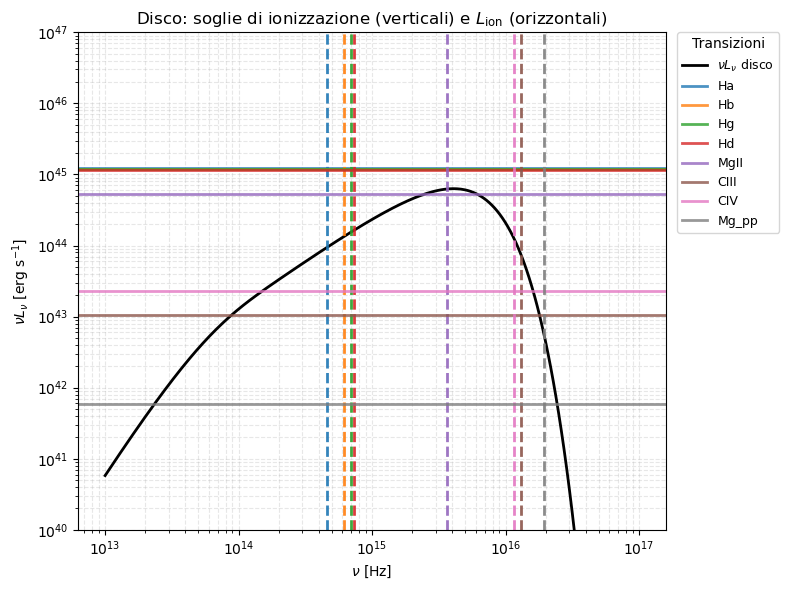

In [38]:
# Plot dello spettro del disco con le soglie di ionizzazione evidenziate, ma ora con nu*L(nu) per vedere meglio il confronto con L_ion
plt.figure(figsize=(8,6))

# curva del disco
plt.loglog(nu, nu*Lnu, lw=2, color="k", label=r'$\nu L_\nu$ disco')
#plt.plot(nu, nu*Lnu, lw=2, color="k", label=r'$\nu L_\nu$ disco')

# colori distinti
cmap = plt.get_cmap("tab10")   
colors = [cmap(i % cmap.N) for i in range(len(names))]

# linee per ogni transizione (stesso colore per verticale+orizzontale)
for (n, nui, Li, col) in zip(names, nu_ion_list, Lion_list, colors):
    plt.axvline(nui, ls="--", lw=2, alpha=0.9, color=col)
    plt.axhline(Li, ls="-",  lw=2, alpha=0.8, color=col, label=str(n))

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]')
plt.ylim(1e40, 1e47)
plt.title(r'Disco: soglie di ionizzazione (verticali) e $L_{\rm ion}$ (orizzontali)')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.legend(title="Transizioni", fontsize=9, title_fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

plt.tight_layout()
plt.show()


In [39]:
#ATTENZIONE 
print("Ldisk =", Ldisk)   # --> viene risultato sbagliato, faccio progrm staccato senze le 4 prove così non mi confondo e uso questo progrm per testare il modello di emissione del disco

Ldisk = 3.9e+45
